In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LIBRARIES

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torchvision.models import DenseNet121_Weights
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

INPUTS

In [ ]:
IMG_HEIGHT=224
IMG_WIDTH =224
IMG_CHANNELS=3
CLASS_NAMES=["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [ ]:
transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dir ="/content/drive/MyDrive/flower_images/train"
val_dir = "/content/drive/MyDrive/flower_images/val"

train_data= datasets.ImageFolder(root=train_dir, transform=transform)
val_data= datasets.ImageFolder(root=val_dir, transform = val_transform)

train_dataset = DataLoader(train_data, batch_size=16, shuffle=True)
val_dataset = DataLoader(val_data, batch_size = 16)

NETWORK ARCHITECTURE

In [ ]:
model = models.densenet121(weights=DenseNet121_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad=False

model.classifier = nn.Linear(model.classifier.in_features, len(CLASS_NAMES))

for param in model.classifier.parameters():
    param.requires_grad=True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs, device):
    train_loss= []
    train_acc=[]
    val_loss =[]
    val_acc=[]
    for epoch in range(epochs):
        model.train()
        correct_preds =0
        total_loss =0
        total_samples =0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs= model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct_preds +=(preds==labels).sum().item()
            total_loss += loss.item()
            total_samples += labels.size(0)
        acc = correct_preds/total_samples
        print(f"Epoch {epoch+1}: Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")
        train_loss.append(total_loss)
        train_acc.append(acc)

        model.eval()
        with torch.no_grad():
            eval_preds =0
            eval_loss =0
            eval_samples=0
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)

                eval_preds +=(preds==labels).sum().item()
                eval_loss += loss.item()
                eval_samples += labels.size(0)
            eval_acc =eval_preds/eval_samples
            print(f" Validation Loss: {eval_loss:.4f}, Validation Accuracy: {eval_acc:.4f}")
            val_loss.append(eval_loss)
            val_acc.append(eval_acc)

    return train_loss, train_acc, val_loss, val_acc

TRAINING

In [ ]:
EPOCHS =10
train_loss, train_acc, val_loss, val_acc= train_model(model, criterion, optimizer, train_dataset, val_dataset, EPOCHS, device)

Epoch 1: Loss: 162.1256, Accuracy: 0.7113
 Validation Loss: 32.3607, Validation Accuracy: 0.8360
Epoch 2: Loss: 94.5592, Accuracy: 0.8363
 Validation Loss: 25.9378, Validation Accuracy: 0.8490
Epoch 3: Loss: 79.2310, Accuracy: 0.8597
 Validation Loss: 22.3335, Validation Accuracy: 0.8900
Epoch 4: Loss: 73.1408, Accuracy: 0.8670
 Validation Loss: 20.4740, Validation Accuracy: 0.8950
Epoch 5: Loss: 67.1481, Accuracy: 0.8787
 Validation Loss: 18.9176, Validation Accuracy: 0.8900
Epoch 6: Loss: 64.4627, Accuracy: 0.8830
 Validation Loss: 18.5940, Validation Accuracy: 0.8950
Epoch 7: Loss: 63.3719, Accuracy: 0.8773
 Validation Loss: 17.1731, Validation Accuracy: 0.9110
Epoch 8: Loss: 59.2151, Accuracy: 0.8900
 Validation Loss: 16.5471, Validation Accuracy: 0.9070
Epoch 9: Loss: 60.0200, Accuracy: 0.8937
 Validation Loss: 17.5010, Validation Accuracy: 0.9120
Epoch 10: Loss: 53.1306, Accuracy: 0.9077
 Validation Loss: 16.6508, Validation Accuracy: 0.9030


PLOTTING

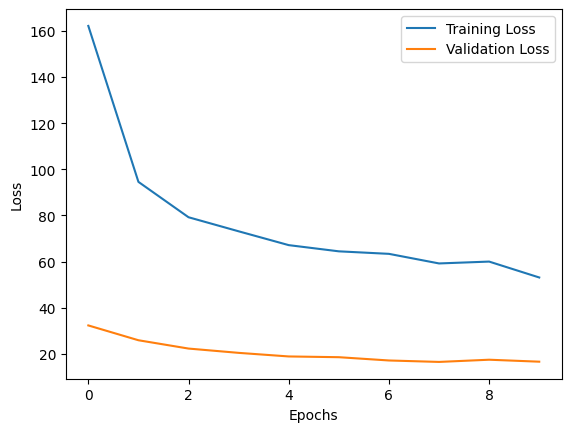

In [ ]:
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

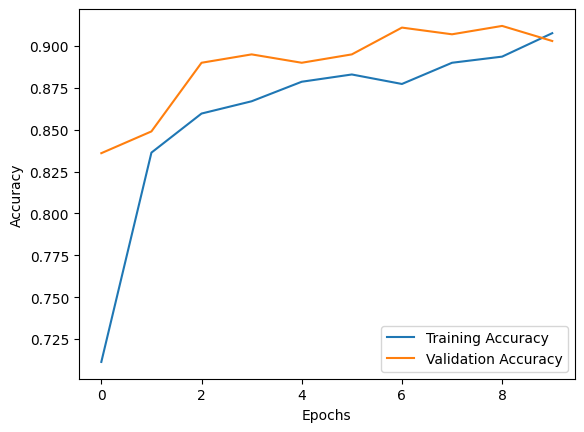

In [ ]:
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()